# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [4]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", master_file.shape)
master_file.head()

Shape of the master file: (48152, 114)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_46477/3102753570.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [5]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [6]:
master_file_clean = master_file.dropna(subset=["FINAL CONFIDENCE GRADING"])

master_file_clean["gene"] = master_file_clean["gene"].str.strip()
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()

print(master_file_clean["FINAL CONFIDENCE GRADING"].unique())

# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim'": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

master_file_clean["grade_ordinal"] = master_file_clean["FINAL CONFIDENCE GRADING"].map(grading_scheme)
master_file_clean = master_file_clean.dropna(subset=["grade_ordinal"])

# remove duplicates
master_file_clean = master_file_clean.drop_duplicates(subset=["mutation", "drug"])
#print(master_file_clean)

# keep only necessary columns
model_df = master_file_clean[[
    "gene",
    "mutation",
    "drug",
    "grade_ordinal"
]].copy()


mutations = sorted(list(model_df['mutation'].unique()))
print(len(mutations))
for m in mutations[:300]:
    print(m)

print(model_df["drug"].unique())
model_df.head()



['4) Not assoc w R - Interim' '5) Not assoc w R'
 '3) Uncertain significance' '2) Assoc w R - Interim' '1) Assoc w R']
19553
LoF
c.-1001G>A
c.-1002C>T
c.-1004G>A
c.-100A>G
c.-100C>A
c.-100C>G
c.-100C>T
c.-100G>A
c.-100T>C
c.-1016C>T
c.-1017G>A
c.-1018C>G
c.-1019C>T
c.-101A>T
c.-101C>G
c.-101G>A
c.-101T>C
c.-101_-51delTGACCTCCGCCGGCGACGATGCAGAGCGCAGCGATGAGGAGGAGCGGCGCT
c.-1021A>G
c.-1022G>A
c.-1023A>C
c.-1025G>A
c.-1028G>A
c.-102A>G
c.-102C>T
c.-102G>A
c.-102G>C
c.-102_-78delGCAACCTTTTGGTCACTCAATCACA
c.-102_-97delTCGGGGinsC
c.-1035C>T
c.-1036T>C
c.-103C>G
c.-103C>T
c.-103G>C
c.-1043T>C
c.-104A>C
c.-104A>G
c.-104C>A
c.-104C>T
c.-104T>C
c.-104_-103insC
c.-104delC
c.-1053G>A
c.-1053G>T
c.-1054C>T
c.-1058G>A
c.-1058G>T
c.-105A>G
c.-105C>G
c.-105C>T
c.-105G>A
c.-105T>C
c.-1061G>T
c.-106A>G
c.-106C>T
c.-106G>A
c.-106G>C
c.-1072C>T
c.-1077G>A
c.-107A>C
c.-107C>G
c.-107G>A
c.-107_-106insT
c.-1085G>A
c.-1086G>A
c.-108A>G
c.-108A>T
c.-108C>T
c.-108G>A
c.-108G>T
c.-1092G>A
c.-1093C>T
c.-1094G>A
c.

,gene,mutation,drug,grade_ordinal
1,bacA,c.1044G>A,Amikacin,0.0
44,bacA,c.-18T>C,Amikacin,2.0
49,bacA,c.-21G>A,Amikacin,2.0
60,bacA,c.-32G>A,Amikacin,2.0
61,bacA,c.-32G>T,Amikacin,2.0


In [7]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((2048, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = model_df.merge(TB_drugs, on="drug", how="left")
final_data.head()

,gene,mutation,drug,grade_ordinal,smiles,fingerprint
0,bacA,c.1044G>A,Amikacin,0.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,bacA,c.-18T>C,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,bacA,c.-21G>A,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,bacA,c.-32G>A,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,bacA,c.-32G>T,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [8]:
# Ordinal encoding for Mutation, Gene, and Drug\n",
final_data_copy_ec = final_data.copy()
final_data_copy_ec["mutation"] = final_data_copy_ec["mutation"].astype("category").cat.codes
final_data_copy_ec["gene"] = final_data_copy_ec["gene"].astype("category").cat.codes
final_data_copy_ec["drug"] = final_data_copy_ec["drug"].astype("category").cat.codes
final_data_copy_ec["smiles"] = final_data_copy_ec["smiles"].astype("category").cat.codes

final_data_copy_ec.head()

,gene,mutation,drug,grade_ordinal,smiles,fingerprint
0,17,2682,0,0.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,17,772,0,2.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,17,960,0,2.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,17,1350,0,2.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,17,1351,0,2.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


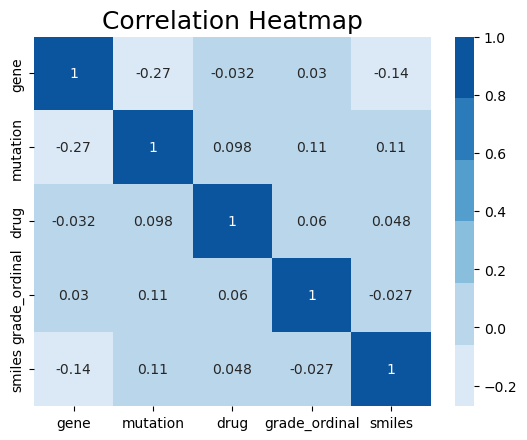

In [9]:

X = final_data_copy_ec.drop(columns=['fingerprint'])

sns.heatmap(X.corr(), annot=True, cmap = sns.color_palette("Blues"))
plt.title('Correlation Heatmap', fontsize = 18)
plt.show()

In [10]:
X_features = X.drop(columns=['grade_ordinal'])
Y = X['grade_ordinal'].astype(int)
X_scaled = StandardScaler().fit_transform(X_features)
XS_df = pd.DataFrame(X_scaled, columns=X_features.columns)


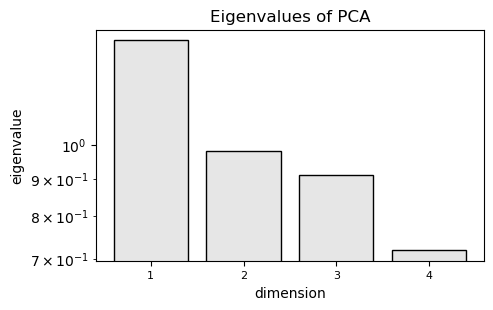

In [11]:
out = PCA(n_components=4).fit(XS_df)
eigenVec = out.components_
eigenVal = out.explained_variance_
eigenX = out.transform(XS_df)
xplot = np.arange(1, 5)

fig = plt.figure(figsize=(5, 3))
plt.bar(xplot, eigenVal, color = (0.9, 0.9, 0.9), edgecolor = 'black')
plt.xlabel('dimension')
plt.ylabel('eigenvalue')
plt.yscale('log')
plt.xticks(xplot, size=8)
plt.title('Eigenvalues of PCA')
plt.show()

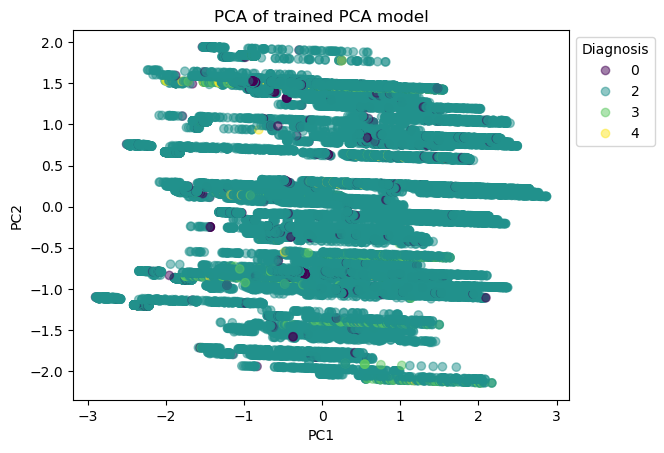

In [12]:
colors = Y

scatter = plt.scatter(x=eigenX[:, 0], y=eigenX[:,1], c=colors, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of trained PCA model')
handles, labels = scatter.legend_elements()
plt.legend(handles, labels, title="Diagnosis", bbox_to_anchor=(1, 1), loc='upper left')


   gene  mutation  drug  grade_ordinal  \
0    17      2682     0            0.0   
1    17       772     0            2.0   
2    17       960     0            2.0   
3    17      1350     0            2.0   
4    17      1351     0            2.0   

                                              smiles  
0  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...  
1  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...  
2  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...  
3  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...  
4  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...  
   gene  mutation  drug
0    17      2682     0
1    17       772     0
2    17       960     0
3    17      1350     0
4    17      1351     0


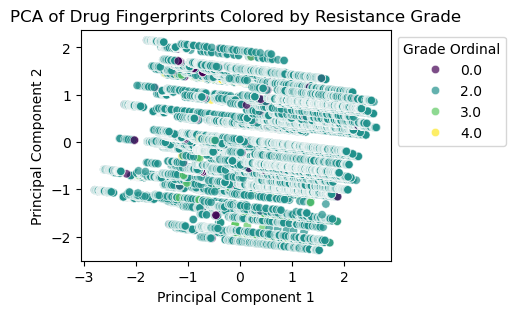

/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_46477/1647265074.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance, palette="viridis")


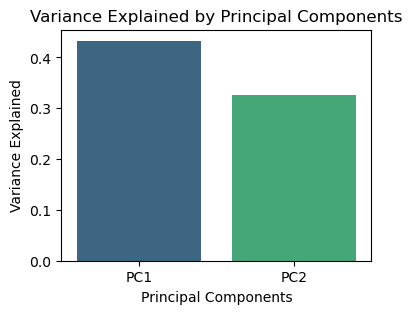

In [13]:
# Ordinal encoding for Mutation, Gene, and Drug\n",
final_data_copy = final_data.copy().drop(columns=["fingerprint"])
final_data_copy["mutation"] = final_data_copy["mutation"].astype("category").cat.codes
final_data_copy["gene"] = final_data_copy["gene"].astype("category").cat.codes
final_data_copy["drug"] = final_data_copy["drug"].astype("category").cat.codes
#final_data_copy["smiles"] = final_data_copy["smiles"].astype("category").cat.codes

print(final_data_copy.head())

# Perform PCA with grade ordinal as the target variable and the fingerprints as features and graph the first two principal components colored by the grade ordinal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the features
features = final_data_copy.drop(columns=["smiles", "grade_ordinal"])
features_scaled = StandardScaler().fit_transform(features)
print(features.head())

# Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features_scaled)

# Create a DataFrame with the principal components and the target variable
pca_df = pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
pca_df["grade_ordinal"] = final_data_copy["grade_ordinal"].values

# Plot the PCA results
plt.figure(figsize=(4, 3))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="grade_ordinal", palette="viridis", alpha=0.7)
plt.title("PCA of Drug Fingerprints Colored by Resistance Grade")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Grade Ordinal", bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

# graph the variance explained by the principal components
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(4, 3))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance, palette="viridis")
plt.title("Variance Explained by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()

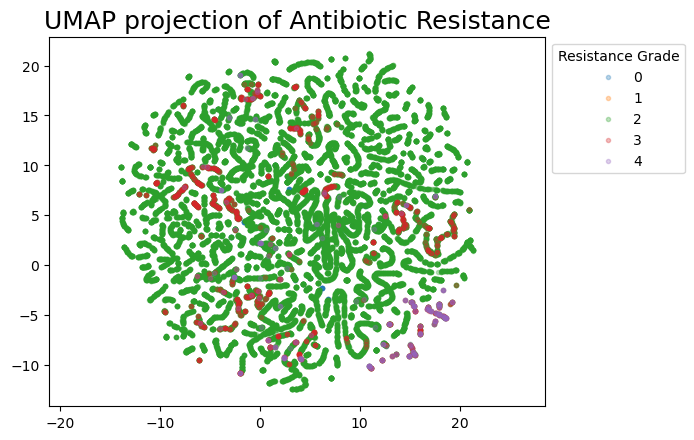

In [14]:
newXY= umap.UMAP().fit_transform(XS_df)

for i in range(np.max(Y)+1):
    idx = np.argwhere(Y == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.', alpha = 0.3, label = str(i))

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of Antibiotic Resistance', fontsize = 18)
plt.legend(title="Resistance Grade", bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [ ]:

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- Check how many fell through to unknown ---
print(one_hot_df['mut_type'].value_counts())
unknown_mask = one_hot_df['mut_type'] == 'unknown'
print(f"\n{unknown_mask.sum()} unparsed mutations:")
for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
    print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['mut_type', 'ref', 'alt'], dummy_na=True)


print(f"num features: {len(one_hot_df.columns)}")
print(one_hot_df.columns)
one_hot_df.head()

mut_type
missense      22568
SNV            8223
frameshift     2074
del             598
nonsense        582
ins             263
delins          229
dup             225
extension        47
LoF              15
uncertain        14
Name: count, dtype: int64

0 unparsed mutations:
num features: 63
Index(['gene', 'mutation', 'drug', 'grade_ordinal', 'position', 'del_len',
       'ins_len', 'mut_type_LoF', 'mut_type_SNV', 'mut_type_del',
       'mut_type_delins', 'mut_type_dup', 'mut_type_extension',
       'mut_type_frameshift', 'mut_type_ins', 'mut_type_missense',
       'mut_type_nonsense', 'mut_type_uncertain', 'mut_type_nan', 'ref_*',
       'ref_A', 'ref_C', 'ref_D', 'ref_E', 'ref_F', 'ref_G', 'ref_H', 'ref_I',
       'ref_K', 'ref_L', 'ref_M', 'ref_N', 'ref_P', 'ref_Q', 'ref_R', 'ref_S',
       'ref_T', 'ref_V', 'ref_W', 'ref_Y', 'ref_nan', 'alt_*', 'alt_A',
       'alt_C', 'alt_D', 'alt_E', 'alt_F', 'alt_G', 'alt_H', 'alt_I', 'alt_K',
       'alt_L', 'alt_M', 'alt_N', 'alt_P', 'alt_Q

,gene,mutation,drug,grade_ordinal,position,del_len,ins_len,mut_type_LoF,mut_type_SNV,mut_type_del,...,alt_N,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,alt_nan
1,bacA,c.1044G>A,Amikacin,0.0,1044.0,0.0,0.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
44,bacA,c.-18T>C,Amikacin,2.0,-18.0,0.0,0.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
49,bacA,c.-21G>A,Amikacin,2.0,-21.0,0.0,0.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
60,bacA,c.-32G>A,Amikacin,2.0,-32.0,0.0,0.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
61,bacA,c.-32G>T,Amikacin,2.0,-32.0,0.0,0.0,False,True,False,...,False,False,False,False,False,True,False,False,False,False


In [16]:
final_data_df = pd.DataFrame(final_data["fingerprint"].tolist(), index=final_data.index)
final_data_df.columns = [f"fp_{i}" for i in range(final_data_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([final_data.drop(columns=["fingerprint"]), final_data_df], axis=1)
print(final_ml.shape)
final_ml.head()

(34838, 2053)


,gene,mutation,drug,grade_ordinal,smiles,fp_0,fp_1,fp_2,fp_3,fp_4,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,bacA,c.1044G>A,Amikacin,0.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,bacA,c.-18T>C,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,bacA,c.-21G>A,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,bacA,c.-32G>A,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,bacA,c.-32G>T,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
# Merge one_hot mutations with the fingerprint data
final_ml_with_one_hot = final_ml.merge(one_hot_df.drop(columns=["gene", "mutation", "drug", "grade_ordinal"]), left_index=True, right_index=True)
print(final_ml_with_one_hot.head())

feature_engineered_df = final_ml_with_one_hot.drop(columns=["mutation", "drug", "smiles", "gene"])
print(feature_engineered_df.head())


    gene     mutation      drug  grade_ordinal  \
1   bacA     c.-18T>C  Amikacin            2.0   
44  bacA  p.Arg356Gln  Amikacin            2.0   
49  bacA  p.Arg508Pro  Amikacin            2.0   
60  bacA   p.Asp379fs  Amikacin            2.0   
61  bacA  p.Asp379His  Amikacin            2.0   

                                               smiles  fp_0  fp_1  fp_2  fp_3  \
1   C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...     0     1     0     0   
44  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...     0     1     0     0   
49  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...     0     1     0     0   
60  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...     0     1     0     0   
61  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...     0     1     0     0   

    fp_4  ...  alt_N  alt_P  alt_Q  alt_R  alt_S  alt_T  alt_V  alt_W  alt_Y  \
1      0  ...  False  False  False  False  False  False  False  False  False   
44     0  ...  False  False  False  False  False  Fa

In [31]:
final_ml_with_one_hot.head(10)

,gene,mutation,drug,grade_ordinal,smiles,fp_0,fp_1,fp_2,fp_3,fp_4,...,alt_N,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,alt_nan
1,bacA,c.-18T>C,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
44,bacA,p.Arg356Gln,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
49,bacA,p.Arg508Pro,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
60,bacA,p.Asp379fs,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
61,bacA,p.Asp379His,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False
62,bacA,p.Asp406Ala,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False
63,bacA,p.Asp423Gly,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
67,bacA,p.Asp546Ala,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False
74,bacA,p.Gln618Leu,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
77,bacA,p.Glu433Lys,Amikacin,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False


/Users/Bella/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/Bella/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


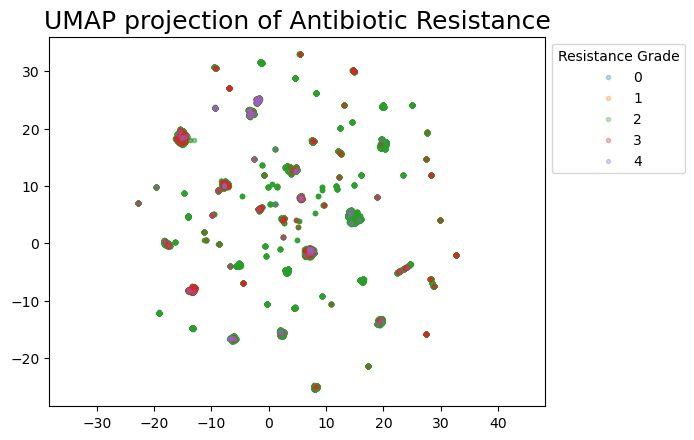

In [18]:
df_clean = feature_engineered_df.dropna()
X = df_clean.drop(columns=["grade_ordinal"]).astype(int)
Y = df_clean["grade_ordinal"].astype(int)

reducer = umap.UMAP(metric='jaccard', min_dist = 0.1, random_state=42, n_neighbors=50, init='random')

newXY= reducer.fit_transform(X)

for i in range(np.max(Y)+1):
    idx = (Y == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.', alpha = 0.3, label = str(i))

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of Antibiotic Resistance', fontsize = 18)
plt.legend(title="Resistance Grade", bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

clf = RandomForestClassifier()
scores = cross_val_score(clf, X, Y, cv=5)

print(scores.mean()) # low accuracy means theres a weak signal between the chemistry and resistance grade


0.32618184277886275


/Users/Bella/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/Bella/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/Bella/miniconda3/lib/python3.13/site-packages/pynndescent/pynndescent_.py:939: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(
/Users/Bella/miniconda3/lib/python3.13/site-packages/umap/umap_.py:127: UserWarning: A few of your vertices were disconnected from the manifold.  This shouldn't cause problems.
Disconnection_distance = 1 has removed 252 edges.
It has only fully disconnected 11 vertices.
Use umap.utils.disconnected_vertices() to identify them.
  warn(


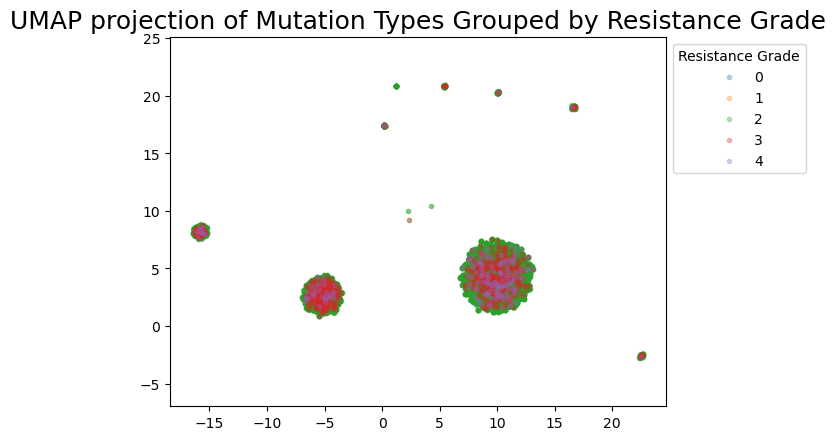

In [20]:
X_mutations = X.filter(regex='^mut_type_')
newXY_mut = umap.UMAP(metric='jaccard', random_state=42, init='random').fit_transform(X_mutations)

for i in range(np.max(Y)+1):
    idx = (Y == i)
    plt.scatter(newXY_mut[idx, 0], newXY_mut[idx, 1], marker = '.', alpha = 0.3, label = str(i))

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of Mutation Types Grouped by Resistance Grade', fontsize = 18)
plt.legend(title="Resistance Grade", bbox_to_anchor=(1, 1), loc='upper left')
plt.show()



/Users/Bella/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/Bella/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


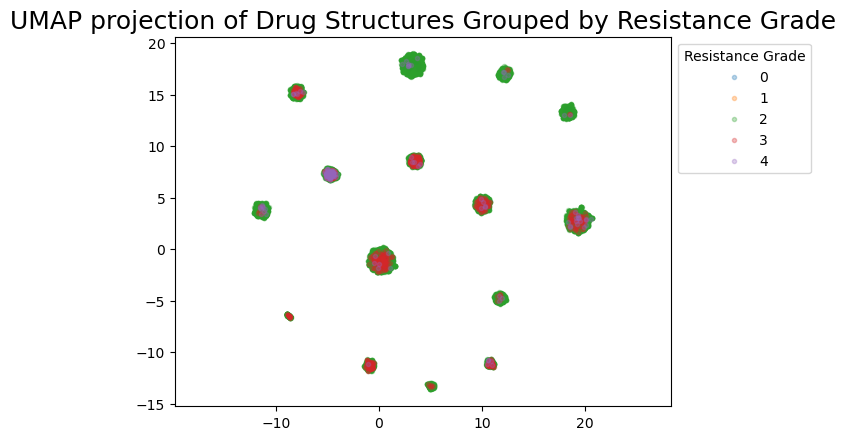

In [22]:
X_fp_only = X.filter(regex='^fp_')
newXY_fp = umap.UMAP(metric='jaccard', random_state=42, init='random').fit_transform(X_fp_only)

for i in range(np.max(Y)+1):
    idx = (Y == i)
    plt.scatter(newXY_fp[idx, 0], newXY_fp[idx, 1], marker = '.', alpha = 0.3, label = str(i))

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of Drug Structures Grouped by Resistance Grade', fontsize = 18)
plt.legend(title="Resistance Grade", bbox_to_anchor=(1, 1), loc='upper left')
plt.show()


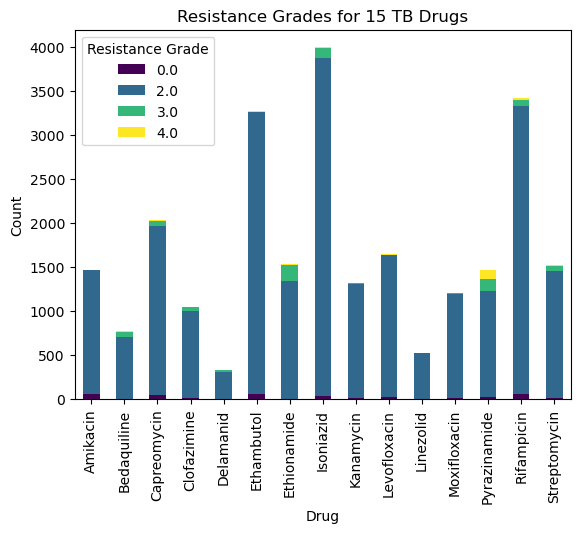

In [39]:
# Let's plot at the 15 drugs and the resistance grades associated with them
drug_grade_counts = final_ml_with_one_hot.groupby('drug')["grade_ordinal"].value_counts().unstack(fill_value=0)
drug_grade_counts.head(15).plot(kind="bar", stacked=True, colormap="viridis")
plt.xlabel("Drug")
plt.ylabel("Count")
plt.title("Resistance Grades for 15 TB Drugs")
plt.legend(title="Resistance Grade")
plt.show()


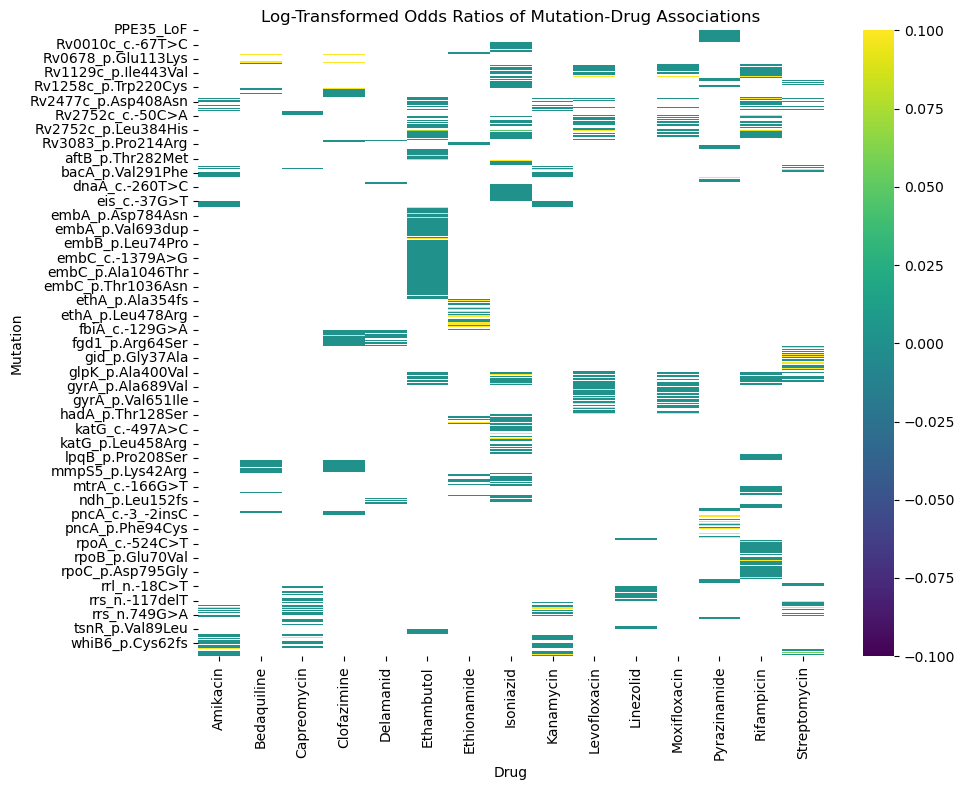

In [56]:
# look at resistance associations with different mutation types
heatmap_df = master_file.pivot_table(index='variant', columns='drug', values='OR_SOLO_DATASET ALL', aggfunc='mean')

#log tranform
heatmap_df = np.log1p(heatmap_df)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df, cmap="viridis")
plt.title("Log-Transformed Odds Ratios of Mutation-Drug Associations")
plt.xlabel("Drug")
plt.ylabel("Mutation")
plt.tight_layout()
plt.show()

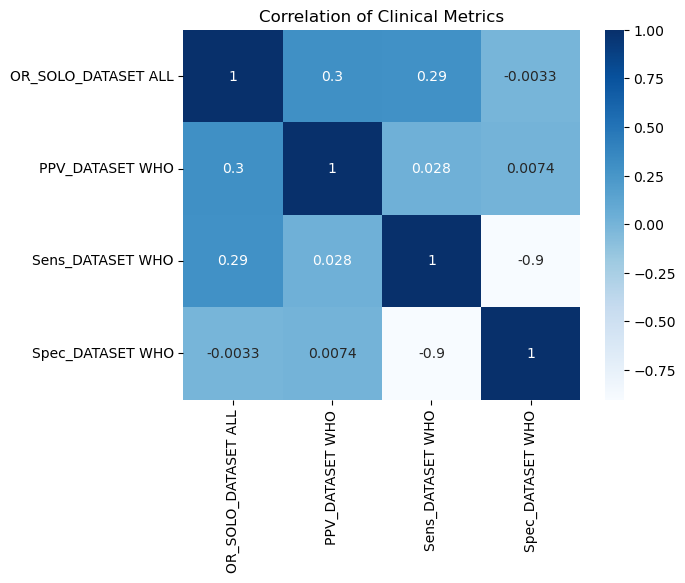

In [65]:
numeric_cols = [
    "OR_SOLO_DATASET ALL", "PPV_DATASET WHO", "Sens_DATASET WHO", "Spec_DATASET WHO"
]

sns.heatmap(master_file[numeric_cols].corr(), annot=True, cmap='Blues')
plt.title("Correlation of Clinical Metrics")
plt.show()